# K-Means Clustering — Customer Complaint Segmentation

## What K-Means Actually Does
K-Means partitions data into `k` groups by alternating two steps until nothing changes:
1. **Assign** every point to its nearest centroid (by Euclidean distance).
2. **Update** each centroid to the mean of the points just assigned to it.

Repeat until assignments stop changing (or a max iteration count is hit). The only thing K-Means is ever doing under the hood is minimizing **inertia** — the total squared distance from every point to its own cluster's centroid. It has no concept of what the data "means"; it is pure geometry over whatever numeric features it's handed.

Two things follow directly from that:
- **The features have to already be numeric and meaningful** before K-Means can do anything useful with them. This notebook loads a ready-made numeric feature matrix built from real customer complaint records (see `../data/text_feature_engineering.ipynb` for how it was derived — a separate data-preparation step, kept out of this notebook, and kept alongside the data it produces rather than here, so this notebook stays focused on K-Means itself).
- **`k` has to be chosen before fitting**, and K-Means will happily produce a "clean-looking" answer for the wrong `k` — it has no way to tell you it's wrong. Section 2 below covers choosing `k` with the **Elbow Method**, using the data alone, without peeking at ground truth.

## Objective
Given a real, pre-built feature matrix representing 6,630 customer complaints across 7 known categories, demonstrate the actual K-Means workflow end to end: choosing `k`, fitting, and then critically evaluating what the algorithm found — where it agrees with the true categories, where it doesn't, and why. The true category is only ever used to *evaluate* the result afterward, never to fit — exactly like a real operational setting where incoming complaints arrive unlabeled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

DATA_DIR = "../data"
RESULT_DIR = "../result"
RANDOM_STATE = 42

## 1. Load the Data

A pre-built numeric feature matrix representing real, unlabeled customer complaint text, plus the original raw complaint text (used later only to read a few examples per cluster, never as an input to K-Means itself).

In [2]:
features_df = pd.read_parquet(f"{DATA_DIR}/complaint_features.parquet")
raw_text_df = pd.read_parquet(f"{DATA_DIR}/complaint_topics_subset.parquet")

feature_cols = [c for c in features_df.columns if c.startswith("feature_")]
X = features_df[feature_cols].to_numpy()
true_labels = features_df["true_label"].to_numpy()
true_label_names = features_df["true_label_name"].tolist()
categories_sorted = sorted(set(true_label_names))

print(f"Feature matrix: {X.shape[0]} complaints x {X.shape[1]} features")
pd.Series(true_label_names).value_counts()

Feature matrix: 6630 complaints x 100 features


PC Hardware               961
Health/Medical Product    958
Automotive                955
Billing/Marketplace       955
Electronics Product       954
Motorcycle/Vehicle        926
Mac Hardware              921
Name: count, dtype: int64

## 2. Choosing k — The Elbow Method

In a real operational setting there's no ground truth to check against — `k` has to be estimated from the data itself. The **Elbow Method** plots inertia (total within-cluster squared distance) against `k`. Inertia always decreases as `k` grows — more clusters can only fit the data at least as well — so the question isn't "which k is lowest" but "where do the returns stop being worth it": the point where the curve bends from a steep drop to a shallow one.

The green line marks the actual number of categories (7) purely so the chart can be sanity-checked against it after the fact — it is not used to pick `k` below.

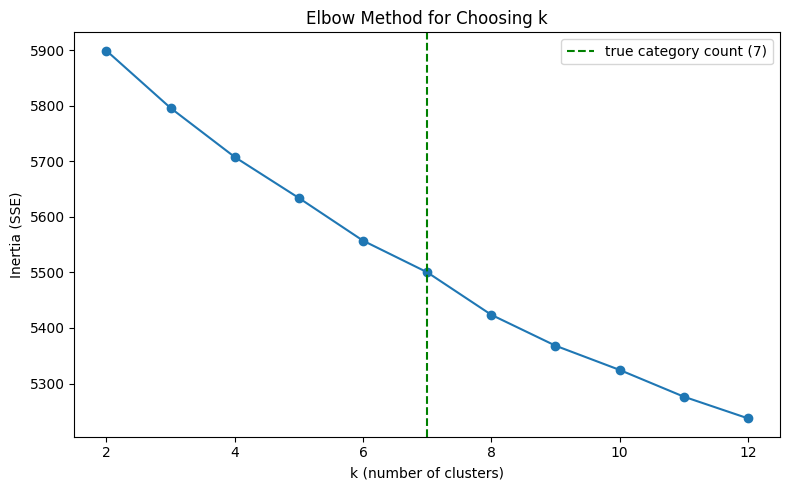

In [3]:
k_range = range(2, 13)
sse = []

for k in k_range:
    km_probe = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_probe.fit(X)
    sse.append(km_probe.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sse, marker='o')
plt.axvline(len(categories_sorted), color='green', linestyle='--', label=f'true category count ({len(categories_sorted)})')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Choosing k')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/elbow_plot.png', dpi=150)
plt.show()

## 3. Fit K-Means at k = 7 and Score Against the True Categories

Now the true labels get used — but only to *evaluate* the fitted model, never to fit it. Two standard clustering-agreement metrics, both scaled 0 (random) to 1 (perfect match), and both correct for chance agreement (unlike raw accuracy, which doesn't even apply here since K-Means' cluster numbers are arbitrary and don't align to any label order):
- **Adjusted Rand Index (ARI)** — agreement on pairs of complaints (same cluster and same true category, or different cluster and different category).
- **Normalized Mutual Information (NMI)** — how much knowing a complaint's cluster reduces uncertainty about its true category.

In [4]:
K = len(categories_sorted)
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
pred_labels = km.fit_predict(X)

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
print(f"Adjusted Rand Index    : {ari:.3f}")
print(f"Normalized Mutual Info : {nmi:.3f}")

Adjusted Rand Index    : 0.291
Normalized Mutual Info : 0.391


## 4. Cluster vs. True Category — Confusion Heatmap

Even a strong ARI/NMI number hides *where* the confusion is. This heatmap shows whether each cluster maps cleanly onto one category or blends several — and if it blends, which ones (a real ops team would read this exact chart to decide whether two categories need to be merged, split, or handled with extra care downstream).

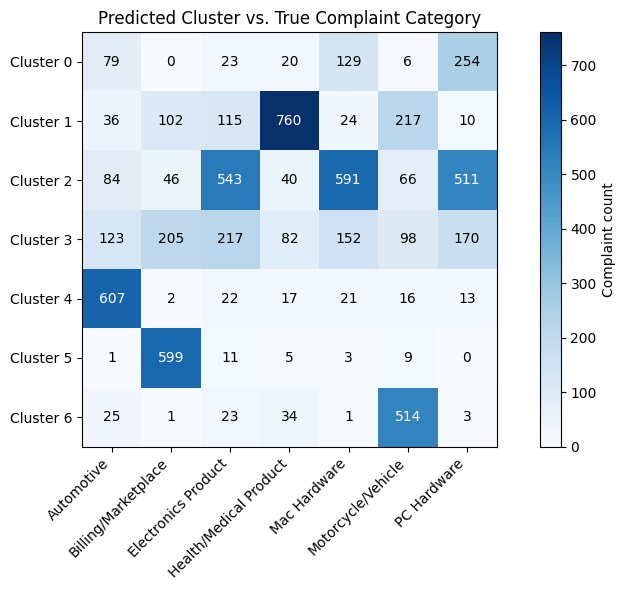

In [5]:
ct = pd.crosstab(pd.Series(pred_labels, name='Cluster'), pd.Series(true_label_names, name='True Category'))
ct = ct[categories_sorted]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels([f'Cluster {i}' for i in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, val, ha='center', va='center',
                 color='white' if val > ct.values.max() / 2 else 'black')
ax.set_title('Predicted Cluster vs. True Complaint Category')
fig.colorbar(im, ax=ax, label='Complaint count')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/cluster_vs_category_heatmap.png', dpi=150)
plt.show()

## 5. What's Actually In Each Cluster? Reading Real Examples

In a real ops setting nobody hands you labels — this is how you'd actually get a feel for what an auto-discovered segment contains: pull a few of the real complaints assigned to it and read them. No feature-engineering internals needed, just the original text lined back up against each complaint's cluster assignment.

In [6]:
cluster_df = raw_text_df.copy()
cluster_df["cluster"] = pred_labels

for c in range(K):
    size = (cluster_df["cluster"] == c).sum()
    print(f"\n=== Cluster {c}  (n={size}) ===")
    sample = cluster_df[cluster_df["cluster"] == c].sample(2, random_state=RANDOM_STATE)
    for _, row in sample.iterrows():
        snippet = row["text"].strip().replace("\n", " ")[:160]
        print(f"  - [{row['category']}] {snippet}...")


=== Cluster 0  (n=511) ===
  - [PC Hardware] : I just bought a new IDE hard drive for my system to go with the one : I already had.  My problem is this.  My system only had a IDE cable : for one drive, so ...
  - [Automotive] Apple IIgs Imagewriter II COLOR printer Color RGB monitor 3.5" DRIVE 5.25" drive keyboard Mouse lots of disks some applications most manuals...

=== Cluster 1  (n=1264) ===
  - [Mac Hardware] Of course, if you want to check the honesty of your dealler, take it in knowing what's wrong, and ask them to tell you. :)  Of course he'll probably know right ...
  - [Health/Medical Product] [riveting BMWMOA election soap-opera details deleted]   I'm going to buy a BMW just to cast a vote for Groucho.  Ride safe, ------------------------------------...

=== Cluster 2  (n=1881) ===
  - [Electronics Product] My next project is to come up with an IF/detector module for fast -- 112 to 250 kB/sec -- packet radio use.  No fancy modulation scheme, just wide FSK for use a...
  - [

## 6. 2D View — Predicted Clusters vs. True Categories, Side by Side

Only 2 of the feature matrix's 100 features can be plotted directly, so this is a rough sanity check rather than the real evidence (that's the ARI/NMI and heatmap above) — but it's still informative to see how much structure survives such a narrow slice.

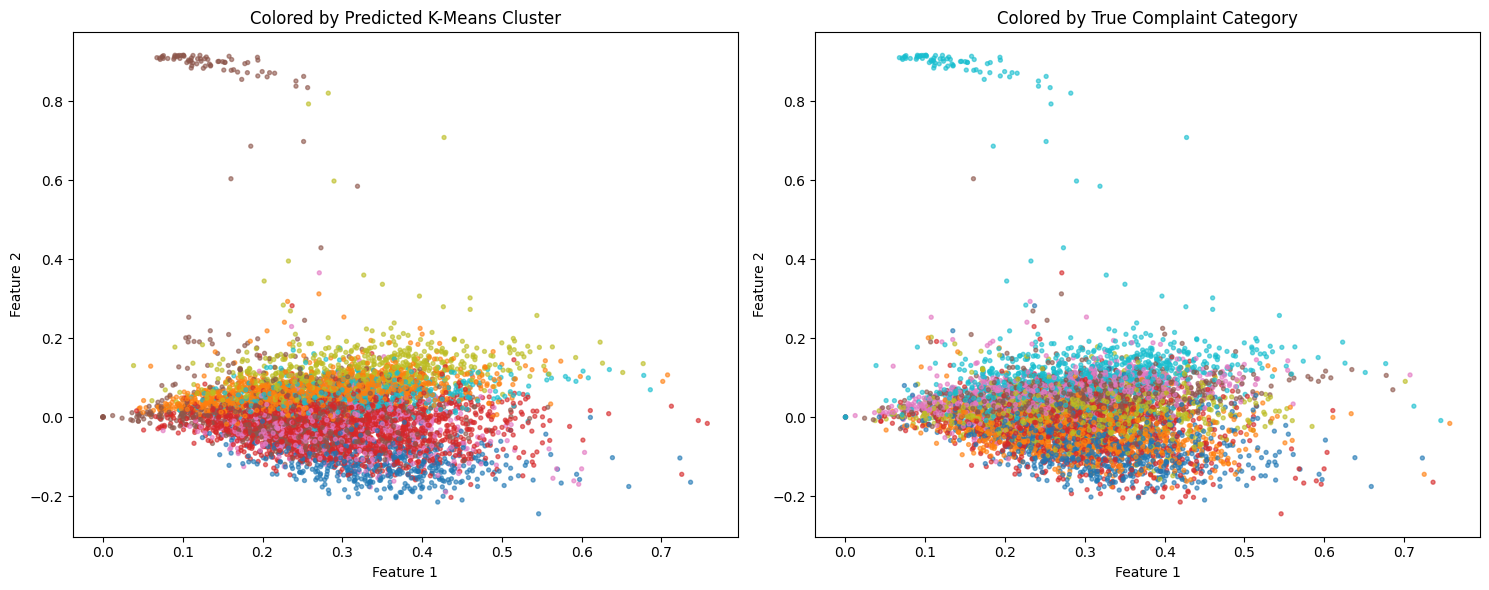

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X[:, 0], X[:, 1], c=pred_labels, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('Colored by Predicted K-Means Cluster')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

axes[1].scatter(X[:, 0], X[:, 1], c=true_labels, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title('Colored by True Complaint Category')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/2d_clusters_vs_categories.png', dpi=150)
plt.show()

## Conclusion

**Results** (see the printed cells and charts above): ARI = 0.29, NMI = 0.39 on 6,630 real, unlabeled complaints across 7 categories — clearly and substantially above the ARI = 0 / NMI = 0 chance baseline, but well short of a clean 1.0 recovery. That gap is the honest, useful finding here, not a shortcoming to explain away: five of the seven categories (Billing/Marketplace, Motorcycle/Vehicle, Health/Medical, PC Hardware, Automotive) map onto a cluster cleanly enough to recognize from its real examples alone; Mac Hardware and Electronics Product blend into two larger, vaguer clusters — the confusion heatmap shows exactly where.

**Operational read:** with zero manually-labeled examples, K-Means recovers most of the real category structure directly from the complaint data, well enough to pre-sort the bulk of incoming volume and cut manual triage load — but it is not accurate enough on its own to fully automate routing for categories that overlap this much. That's the same conclusion an operations team would need to reach: K-Means is a strong first-pass triage layer, not a drop-in replacement for a routing rule (or a human) on the categories it can't cleanly separate. Reading a few real complaints per cluster is what makes this usable in practice either way — it lets someone assign a human-readable name to each auto-discovered segment without pre-existing labels, then decide per-cluster whether to trust it or route it for a closer look.